# Homework 3: DataFrames, Control Flow, and Probability

## Due Saturday, October 25th at 11:59PM

Welcome to Homework 3! This homework will cover lots of different topics:
- Grouping with subgroups (see [BPD 11](https://notes.dsc10.com/02-data_sets/groupby.html#subgroups))
- Merging DataFrames (see [BPD 13](https://notes.dsc10.com/02-data_sets/merging.html))
- Conditional statements (see [CIT 9.1](https://inferentialthinking.com/chapters/09/1/Conditional_Statements.html))
- Iteration (see [CIT 9.2](https://inferentialthinking.com/chapters/09/2/Iteration.html))
- Probability (see [CIT 9.5](https://inferentialthinking.com/chapters/09/5/Finding_Probabilities.html))

### Instructions

Remember to start early and submit often. You are given six slip days throughout the quarter to extend deadlines. See the syllabus for more details. With the exception of using slip days, late work will not be accepted unless you have made special arrangements with your instructor.

**Important**: For homeworks, the `otter` tests don't usually tell you that your answer is correct. More often, they help catch careless mistakes. It's up to you to ensure that your answer is correct. If you're not sure, ask someone (not for the answer, but for some guidance about your approach). These are great questions for office hours (the schedule can be found [here](https://dsc10.com/calendar)) or Campuswire. Directly sharing answers is not okay, but discussing problems with the course staff or with other students is encouraged. 

In [1]:
# Please don't change this cell, but do make sure to run it.
import babypandas as bpd
import matplotlib.pyplot as plt
plt.style.use('seaborn-colorblind')
plt.rcParams['figure.figsize'] = (10, 5)

import numpy as np
import otter
grader = otter.Notebook()

# We need to import some extra packages for some fun demonstrations.
import json
from ipywidgets import interact, widgets
from IPython.display import YouTubeVideo, HTML, display, clear_output, Image, IFrame

# Don't worry about this.
def read_json(path):
    f = open(path, 'r')
    return json.load(f)

### Supplemental Video on DataHub and Jupyter Notebooks

In Lab 0, we linked you to a video that walks you through key ideas you should be aware of when working on DataHub and in Jupyter Notebooks, including
- how files are organized on DataHub
- what it means to "restart the kernel"
- how to use keyboard shortcuts (most important: use `SHIFT + ENTER` to run a cell!) 

Now that you have some experience with Jupyter Notebooks, we're linking this video again for your convenience. If you feel a little shaky on how to work your way around a notebook or troubleshoot issues, we recommend you give it another watch. (When troubleshooting, make sure to always check the [Debugging](https://dsc10.com/debugging/) tab on the course website as well.)

The video is quite long, but if you open the video directly on YouTube (which you can do by clicking the video's title after it loads in the next cell) you'll see timestamps in the description which you can use to jump to different parts of the video depending on what you'd like to learn more about.

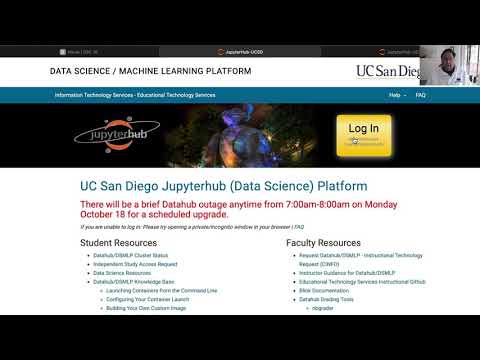

In [2]:
# Run this cell.
YouTubeVideo('Hq8VaNirDRQ')

## 0. Mid-Quarter Survey

We'd like to hear from you on how DSC 10 has been going so far this quarter. To do so, we've put together a survey that asks you to provide feedback on all aspects of the course. You can provide as much or as little detail as you'd like. We value your input and will use the results of the survey to improve the course!

This survey is entirely anonymous, though you are free to leave your name and email if you want. The responses to the survey will be visible to both course staff and the Data Science Student Representatives. There will also be a question at the end of the survey that will allow you to provide feedback on the DSC program as a whole.

<center><h3>Click <a href="https://docs.google.com/forms/d/e/1FAIpQLSe1GW42dTvBEGNmazkLwpfLDudML4Jw967Cffnou1hpj-GoKw/viewform?usp=header">here</a> to access the survey.</h3></center>

After completing the survey, enter the keyword provided at the end of the survey to get credit towards this homework assignment.

In [3]:
survey_keyword = 'Turtle'

In [4]:
grader.check("q0")

q0 results: All test cases passed!

## 1. 100 Years of "K" Baby Names 👶🏻

What letter does your first name start with? In this problem, we'll look more generally at baby names starting with the letter "K". The file `data/baby_names.csv` contains information from the [Social Security Administration](https://www.ssa.gov/oact/babynames/limits.html) about "K" baby names in the US over the course of 100 years. Run the cell below to read in the data.

In [5]:
baby = bpd.read_csv('data/baby_names.csv')
baby

,State,Gender,Year,Name,Count
0,AL,F,1924,Katie,131
1,AL,F,1924,Katherine,108
2,AL,F,1924,Kathleen,96
3,AL,F,1924,Kathryn,67
4,AL,F,1924,Kate,13
...,...,...,...,...,...
398432,WV,M,2023,Kolson,6
398433,WV,M,2023,Kairo,5
398434,WV,M,2023,Kaison,5
398435,WV,M,2023,Kyle,5


The DataFrame `baby` has a row for each `'State'` (50 US states plus Washington DC), `'Gender'` (`'M'` or `'F'`, as assigned at birth), `'Year'` (between 1924 and 2023), and `'Name'`. The `'Count'` column records the number of babies of that gender who were given that name in one state in one year.

Below, we look at only the rows corresponding to the name `Kevin`.

In [6]:
baby[baby.get('Name') == 'Kevin']

,State,Gender,Year,Name,Count
141,IL,M,1924,Kevin,5
196,MA,M,1924,Kevin,6
329,NY,M,1924,Kevin,14
650,IL,M,1925,Kevin,7
705,MA,M,1925,Kevin,6
...,...,...,...,...,...
397816,UT,M,2023,Kevin,16
397972,VA,M,2023,Kevin,63
398154,WA,M,2023,Kevin,34
398312,WI,M,2023,Kevin,24


The first row of the DataFrame shows that there were 5 male babies named Kevin born in Illinois in 1924. There are many other rows corresponding to a `'Name'` of Kevin, which come from other years, other states, and also female babies named Kevin, of which there are some!


Run the cell below to find out when and where many female Kevins were born.

In [7]:
female_kevins = baby[(baby.get('Name') == 'Kevin') & (baby.get('Gender') == 'F')]
female_kevins.sort_values(by='Count', ascending=False)

,State,Gender,Year,Name,Count
154250,CA,F,1991,Kevin,35
167142,CA,F,1993,Kevin,27
180412,CA,F,1995,Kevin,25
142053,CA,F,1989,Kevin,24
148017,CA,F,1990,Kevin,21
...,...,...,...,...,...
81189,DC,F,1974,Kevin,5
79024,MO,F,1973,Kevin,5
78407,IN,F,1973,Kevin,5
78309,IL,F,1973,Kevin,5


**Question 1.1.** There are many more male Kevins than female Kevins. Create a line plot that shows how the number of male babies named Kevin has changed over time in the US. Then use your plot to answer the question that follows.

<AxesSubplot:xlabel='Year'>

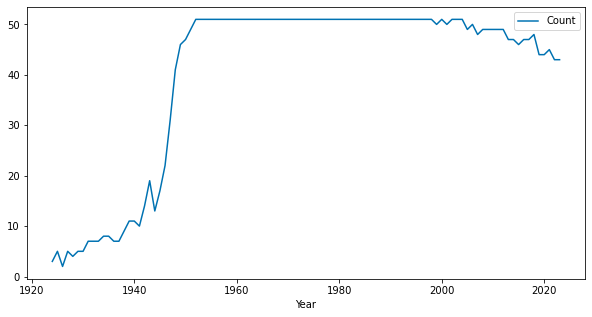

In [8]:
# Create your line plot here.
baby[(baby.get('Name') == 'Kevin') & (baby.get('Gender') == 'M')].groupby('Year').count().plot(kind = 'line', y = 'Count')

Around what year was the peak in popularity for the name Kevin for male babies? Choose the closest answer from the options below and set `male_kevin_peak` to 1, 2, 3, or 4 corresponding to your answer choice.
1. 1960
1. 1970
1. 1980
1. 1990

In [9]:
male_kevins_peak = 1

In [10]:
grader.check("q1_1")

q1_1 results: All test cases passed!

**Question 1.2.** In the `baby` DataFrame, how many babies of each gender were born in each state? Create a DataFrame named `num_babies` with one row for each gender in each state and columns `'State'`, `'Gender'`, and `'Count'`, which contains the total number of babies of each gender in each state with a "K" name. The first few rows of `num_babies` are shown below.

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>State</th>
      <th>Gender</th>
      <th>Count</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>AK</td>
      <td>F</td>
      <td>16516</td>
    </tr>
    <tr>
      <th>1</th>
      <td>AK</td>
      <td>M</td>
      <td>8949</td>
    </tr>
    <tr>
      <th>2</th>
      <td>AL</td>
      <td>F</td>
      <td>150783</td>
    </tr>
    <tr>
      <th>3</th>
      <td>AL</td>
      <td>M</td>
      <td>86306</td>
    </tr>
  </tbody>
</table>

***Hints:***
- You can do this in one line of code.
- Don't forget to use `.reset_index()`.


In [11]:
num_babies = baby.groupby(['State','Gender']).sum().get(['Count']).reset_index()
num_babies

,State,Gender,Count
0,AK,F,16516
1,AK,M,8949
2,AL,F,150783
3,AL,M,86306
4,AR,F,85023
...,...,...,...
97,WI,M,119066
98,WV,F,74535
99,WV,M,37879
100,WY,F,13881


In [12]:
grader.check("q1_2")

q1_2 results: All test cases passed!

A gendered name is a combination of a name and a gender, such as female Kevins. Let's explore the average age of people with each gendered name. For example, let's calculate the average age of all female Kevins. Start by running the cell below to see the `female_kevins` DataFrame.

In [13]:
female_kevins

,State,Gender,Year,Name,Count
15618,CA,F,1947,Kevin,5
16938,CA,F,1948,Kevin,7
18263,CA,F,1949,Kevin,6
19086,NY,F,1949,Kevin,5
21199,CA,F,1951,Kevin,10
...,...,...,...,...,...
248088,NY,F,2004,Kevin,5
257438,TX,F,2005,Kevin,6
259290,CA,F,2006,Kevin,6
260362,GA,F,2006,Kevin,5


We'll define the age of a person as 2025 (the current year) minus the year in which the person was born. This doesn't take into account people's birthdays, because we don't have that information. For example, if a female Kevin was born in 1985, they will be counted as 2025 - 1985 = 40 years old. Therefore the **total age** of all the female Kevins is given below.

In [14]:
total_age = ((2025 - female_kevins.get('Year')) * female_kevins.get('Count')).sum()
total_age

124149

To find the average age, we need to know how many female Kevins there are. The **total count** of female Kevins is given below.

In [15]:
total_count = female_kevins.get('Count').sum()
total_count

2556

Therefore the **average age** of female Kevins is given below.

In [16]:
average_age = total_age / total_count
average_age

48.571596244131456

Notice that we _cannot_ calculate the average age of female Kevins as follows.

In [17]:
age = 2025 - female_kevins.get('Year')
age.mean()

49.57728706624606

This is incorrect because it does not take into account the fact that there were more female Kevins born some years than others. 

**Question 1.3.** Create a DataFrame named `avg_age` that has one row for each gendered name and columns `'Gender'`, `'Name'`, and `'Average_Age'`, which contains the average age of all people with each gendered name. The first few rows of `avg_age` are shown below.

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Gender</th>
      <th>Name</th>
      <th>Average_Age</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>F</td>
      <td>Ka</td>
      <td>35.372781</td>
    </tr>
    <tr>
      <th>1</th>
      <td>M</td>
      <td>Ka</td>
      <td>34.000000</td>
    </tr>
    <tr>
      <th>2</th>
      <td>F</td>
      <td>Kaaliyah</td>
      <td>18.636364</td>
    </tr>
    <tr>
      <th>3</th>
      <td>M</td>
      <td>Kaan</td>
      <td>13.186364</td>
    </tr>
  </tbody>
</table>

***Hints:***
- Before attempting this question, make sure you understand the strategy shown above for finding the average age of female Kevins. You will need to generalize this approach.
- This is a multi-step problem. Add cells and display your intermediate results so you can see your progress as you go.
- Our first step was to add a new column to the DataFrame called `TotalAge`. 


In [18]:
avg_age = (baby.assign(Total_Age = (2025 - baby.get('Year')) * baby.get('Count'))
           .groupby(['Name','Gender'])
           .sum()
          )
avg_age = (avg_age.assign(Average_Age = avg_age.get('Total_Age')/ avg_age.get('Count'))
           .reset_index()
           .get(['Gender','Name','Average_Age'])
          )
avg_age

,Gender,Name,Average_Age
0,F,Ka,35.372781
1,M,Ka,34.000000
2,F,Kaaliyah,18.636364
3,M,Kaan,13.186364
4,F,Kaaren,81.233449
...,...,...,...
2645,F,Kyung,68.509091
2646,M,Kyzen,3.330000
2647,M,Kyzer,5.441501
2648,M,Kyzier,2.000000


In [19]:
grader.check("q1_3")

q1_3 results: All test cases passed!

## 2. Txting Abbrevs 📲

A new language of acronyms and texting abbreviations has evolved and become embedded in texting and internet culture. For this question, we'll be exploring some data on texting abbreviation. Run the cell below to read in the data.

In [20]:
texting_raw = bpd.read_csv('data/texting.csv')
texting_raw

,Abbreviation and Meaning
0,AFAIK - As far as I know
1,AKA - Also known as
2,AMA - Ask me anything
3,AMAA - Ask me almost anything
4,ASAP - As soon as possible
...,...
105,Yeet - To throw something or used as an exclam...
106,YGTI - You get the idea
107,YMMV - Your mileage may vary
108,YOLO - You only live once


This *raw* data is not quite ready for analysis. To prepare the data for analysis (or "clean" it), let's separate each abbreviation from its meaning.

**Question 2.1.** Write a function named `get_abbr` that takes in a string `combined` in the form of `"abbreviation - meaning"` and returns the abbreviation. Next, write another function named `get_meaning` that also takes in a string of the same form and returns the meaning.

For example, `get_abbr("AFAIK - As far as I know")` should return `"AFAIK"`, and `get_meaning("AFAIK - As far as I know")` should return `"As far as I know"`.

In [21]:
def get_abbr(combined):
    return combined.split(' - ')[0]

def get_meaning(combined):
    return combined.split(' - ')[1]
    
# Test your functions on an example input.
# Feel free to play around until you're confident that your functions work correctly.
print(get_abbr("AFAIK - As far as I know"))
print(get_meaning("AFAIK - As far as I know"))

AFAIK
As far as I know


In [22]:
grader.check("q2_1")

q2_1 results: All test cases passed!

**Question 2.2.** Now, let's use the functions we wrote to separate the abbreviation from the meaning. Create a new DataFrame named `texting` with one row for each abbreviation in `texting_raw` and with two columns, `'Abbreviation'` and `'Meaning'`.

In [23]:
texting = texting_raw.assign(Abbreviation = texting_raw.get('Abbreviation and Meaning').apply(get_abbr), Meaning = texting_raw.get('Abbreviation and Meaning').apply(get_meaning)).get(['Abbreviation','Meaning'])
texting

,Abbreviation,Meaning
0,AFAIK,As far as I know
1,AKA,Also known as
2,AMA,Ask me anything
3,AMAA,Ask me almost anything
4,ASAP,As soon as possible
...,...,...
105,Yeet,To throw something or used as an exclamation
106,YGTI,You get the idea
107,YMMV,Your mileage may vary
108,YOLO,You only live once


In [24]:
grader.check("q2_2")

q2_2 results: All test cases passed!

One of our DSC 10 tutors collected some data on their own most-used abbreviations in their recent texts. The DataFrame `tutor` contains their top ten most-used abbreviations and the number of times they used each one in the past month.

In [25]:
tutor = bpd.read_csv('data/tutors_data.csv').set_index('Abbreviation')
tutor

,Count
Abbreviation,
LOL,87
YP,83
IDK,75
LMK,73
OMG,59
JK,52
OMW,50
TBH,31
OFC,24


Now we want to figure out what these abbreviations mean by looking up their meanings in the `texting` DataFrame.

**Question 2.3.** Combine the `texting` and `tutor` DataFrames into a single DataFrame named `tutor_with_meaning` using the `merge` method. The new `tutor_with_meaning` DataFrame should have these 3 columns, in this order: `'Abbreviation'`, `'Meaning'`, and `'Count'`. Organize the rows from most-frequently used abbreviation to least, as in the `tutor` DataFrame.

In [26]:
tutor_with_meaning = texting.merge(tutor.reset_index(), on = 'Abbreviation').sort_values('Count',ascending = False)
tutor_with_meaning

,Abbreviation,Meaning,Count
3,LOL,Laughing out loud,87
9,YP,Yes please,83
0,IDK,I don’t know,75
2,LMK,Let me know,73
5,OMG,Oh my god/gosh,59
1,JK,Just kidding,52
6,OMW,On my way,50
8,TBH,To be honest,31
4,OFC,Of course,24
7,Sus,Suspicious,8


In [27]:
grader.check("q2_3")

q2_3 results: All test cases passed!

## 3. Triton Tweets 🧜‍♂️💬


<img src = "images/triton_logo.jpg" width=200>

UCSD is starting it's own messaging app called Triton Tweets exclusive to staff and students! One of the key features of Triton Tweets is that when students send out messages, an emoji representing their college is automatically added to the end of their message. Your job in this question is to decide what emoji represents each college and to add these emojis to their tweets, using Python dictionaries and `for`-loops.

 We'll start by reminding you about Python dictionaries, which we also looked at briefly in Homework 2 (in the question about ramen 🍜). Dictionaries provide a convenient way to store data in `key: value` pairs. Here's an example dictionary you also saw in Homework 2.

In [28]:
dsc_courses = {
    # key: value
    'DSC 10': 'Principles of Data Science',
    'DSC 20': 'Programming and Basic Data Structures for Data Science',
    'DSC 30': 'Data Structures and Algorithms for Data Science',
    'DSC 40A': 'Theoretical Foundations of Data Science I',
    'DSC 40B': 'Theoretical Foundations of Data Science II',
    'DSC 80': 'The Practice and Application of Data Science'
}

We can access the value corresponding to each key using bracket notation.

In [29]:
dsc30_name = dsc_courses['DSC 30']
dsc30_name

'Data Structures and Algorithms for Data Science'

Here, `'DSC 30'` is the key and `'Data Structures and Algorithms for Data Science'` is the value.

We can extract all keys from a dictionary using the .keys() method:

In [30]:
dsc_courses.keys()

dict_keys(['DSC 10', 'DSC 20', 'DSC 30', 'DSC 40A', 'DSC 40B', 'DSC 80'])

We can iterate through all of the keys (or values) of a dictionary if needed. For example:

In [31]:
for course in dsc_courses.keys():
    print('I am taking', course)

I am taking DSC 10
I am taking DSC 20
I am taking DSC 30
I am taking DSC 40A
I am taking DSC 40B
I am taking DSC 80


In Python, emojis can be included as part of a string. For example:

In [32]:
'🐍'

'🐍'

If you remove the quotes from the emoji above and run the cell, you will see `SyntaxError: invalid character`. Make sure that throughout this question, your emojis are contained within strings! (Fun fact, they cannot currently be used as variable names. Try it and see what error you get!)

The website [getemoji.com](https://getemoji.com/) allows you to copy and paste emojis. To select an emoji, double click it to highlight it. Try copying and pasting an emoji of your choice from that site into the code cell below. Alternatively, you can launch an emoji keyboard on your computer; if you're on a Mac, hit the `Control`, `Command`, and `Space` keys on your keyboard at the same time, and if you're using Windows, hit the `Windows` and `.` keys at the same time.

Don't forget to enclose your chosen emoji in quotes!

In [33]:
# Copy and paste any emoji, within quotes, into this code cell.

**Question 3.1** In the cell below, create a dictionary called `colleges` that has the following eight keys:
- `'<Revelle>'` 
- `'<Muir>'`
- `'<Marshall>'`
- `'<Warren>'`
- `'<ERC>'`
- `'<Sixth>'`
- `'<Seventh>'`
- `'<Eighth>'`

The reason why we are writing the college is <> brackets is because the username format for Triton Tweets is "@name\<college\>." Every username is made up of an @ symbol, the student's name, and their college in <> brackets. You can assume that <> characters will never exist within the name portion of the username. By the end of this question, \<college\> will be changed into an emoji.

The values corresponding to each of these eight keys must be emojis, but they can be any emoji you want, as long as:

- they are copied from the site [getemoji.com](https://getemoji.com/), and 
- they are not in the "New Emojis" category at the bottom of the page.

Have fun with it! We've chosen an emoji for `'<Revelle>'` as an example for you, but feel free to change it.

Some troubleshooting tips:

- After defining your dictionary, you may see some emoijs displayed with `'\U001...'` instead of their actual graphic. **If this happens, pick different emojis.**
- If you fail the test case that says your emojis are invalid, and you're certain you correctly defined your dictionary, you may consider choosing other emojis that are more generic that are more likely to be recognized by our autograder. This most likely won't be a problem if you copy your emojis from [getemoji.com](https://getemoji.com/) (the Mac and Windows emoji pickers use lots of new emojis, so it's possible you picked one of those).

In [34]:
colleges = {
    '<Revelle>': '🌞',
    '<Muir>' : '🌲',
    '<Marshall>': '🌸',
    '<Warren>': '🪵',
    '<ERC>': '🌜',
    '<Sixth>': '🦜',
    '<Seventh>': '🦎',
    '<Eighth>': '🐍'
}
colleges

{'<Revelle>': '🌞',
 '<Muir>': '🌲',
 '<Marshall>': '🌸',
 '<Warren>': '🪵',
 '<ERC>': '🌜',
 '<Sixth>': '🦜',
 '<Seventh>': '🦎',
 '<Eighth>': '🐍'}

In [35]:
grader.check("q3_1")

q3_1 results: All test cases passed!

Great! Now, if we want to create strings that use the college emojis, we don't need to copy-paste the emojis themselves – we can just access them from the `colleges` dictionary.

In [36]:
colleges['<Sixth>']

'🦜'

In [37]:
# Remember, the + symbol concatenates strings!
'@Ciro' + colleges['<ERC>']

'@Ciro🌜'

**Question 3.2.** Now, complete the implementation of the function `emojify`, which take as input a string that represents a student's username, with an optional message. The username has the format "@name\<college\>." Every username will be made up of an @ symbol, the student's name, and their college in <> brackets. You can assume that <> characters will never exist within the name portion of the username.  The input can also include a message that goes after the username, and the message can include other students' usernames.

The function should return a new string with each \<college\> replaced by the corresponding emoji from the `colleges` dictionary. Here is how the function would work on various example usernames and tweets. Your emojis may look different depending on what emojis you used in the `colleges` dictionary.

```py
>>> emojify('@Ryan<Revelle>: I love DSC10!')
'@Ryan🌞: I love DSC10!'

>>> emojify('@Kate<Seventh>: Makai is the best dining hall! @Elizabeth<ERC>, want to get lunch sometime?')
'@Kate🕶: Makai is the best dining hall! @Elizabeth🌎, want to get lunch sometime?'

>>> emojify('@Avi<Warren>: Skydiving was awesome, highly recommend. @Leander<Marshall>, you in for next time?')
'@Avi🧸: Skydiving was awesome, highly recommend. @Leander🤝, you in for next time?'
```

***Note:*** As we did in the preceding example, use the dictionary `colleges` to access the emojis – don't actually write any emojis within your function.

***Hints:*** 
- You will need to use a `for`-loop for this question. Refer to the example dictionary from the start of the problem (where we printed `'I am taking DSC 10'`) for some clues on how to start. Our solution code only adds two lines to the skeleton below!
- Use the string method [`.replace`](https://www.w3schools.com/python/ref_string_replace.asp). 

In [38]:
def emojify(tweet):
    tweet_emoji = '<' + tweet.split('<')[1].split('>')[0] + '>'
    for i in colleges:
        if i == tweet_emoji:
            tweet = tweet.split('<')[0] + colleges[i] + tweet.split('<')[1].split('>')[1]
        
    # Don't change this.
    return tweet

# An example call to emojify. Try out some other usernames too.
emojify('@Gary<Warren>: Make sure to start the midterm project early!')

'@Gary🪵: Make sure to start the midterm project early!'

In [39]:
grader.check("q3_2")

q3_2 results: All test cases passed!

### Fun Demo

Run the cell below to produce a text box (don't worry about the code itself). Type a username (@name\<college\>) in the text box and watch it get emojified live! 

In [40]:
def emojify_live(type_here):
    display(HTML('<h2>' + emojify(type_here) + '</h2>'))
interact(emojify_live, type_here="");

interactive(children=(Text(value='', description='type_here'), Output()), _dom_classes=('widget-interact',))

## 4. Alternating Means 🔁

In this problem, we'll define two functions that compute some sort of "alternating mean" of a sequence of values.

**Question 4.1.** Complete the implementation of the function `alternating_mean`, which takes in an array of numbers, `values`, and computes the mean of **every other element** in the original array starting with the element at position 0.

```py
>>> alternating_mean(np.array([3, 1.5, 4, 3.5]))
3.5 # Comes from (3 + 4) / 2.

>>> alternating_mean(np.array([3, 1.5, 4, 3.5, 5.9]))
4.3 # Comes from (3 + 4 + 5.9) / 3.

```

Once you've written your function, you should test it out on several arrays yourself to make sure it works as intended.

***Hint:*** Compute the mean by finding the sum of every other element in the array and dividing it by the number of elements that were summed.

<!--
BEGIN QUESTION
name: q4_1
-->

In [41]:
def alternating_mean(values):
    sum = 0.0
    count = int((len(values) + 1) / 2)
    for i in np.arange(0, len(values), 2):
        sum += values[i]
    return sum / count
    
# Feel free to change this input to make sure your function works correctly.
alternating_mean(np.array([3, 1.5, 4,3.5,5.9]))

4.3

In [42]:
grader.check("q4_1")

q4_1 results: All test cases passed!

**Question 4.2.** In math, the word "alternating" is sometimes used to indicate that the signs of the elements of a sequence oscillate, or "bounce", back and forth between positive and negative. Complete the implementation of the function `alternating_sign_mean`, which takes in an array of positive numbers, `values`, and computes the mean of **_every_ element** in the original array with **alternating signs**, starting with a positive sign for the element at position 0, a negative sign for the element at position 1, and so on. Example behavior is shown below.

```py
>>> alternating_sign_mean(np.array([3, 2, 9.5]))
3.5 # Comes from (3 + (-2) + 9.5) / 3.

>>> alternating_sign_mean(np.array([3, 2.5, 7, 6.5]))
0.25 # Comes from (3 + (-2.5) + 7 + (-6.5)) / 4.
```

***Hint:*** If `x` is an integer, `x % 2` evaluates to 0 when `x` is even and to 1 when `x` is odd. If `x` represents the position of an element in the array, you can use this to help you figure out whether the sign should be positive or negative.

<!--
BEGIN QUESTION
name: q4_2
-->

In [43]:
def alternating_sign_mean(values):
    sum = 0.0
    count = len(values)
    for i in np.arange(0,len(values),1):
        if i % 2 == 0:
            sum += values[i]
        elif i % 2 == 1:
            sum -= values[i]
    return sum / count
    
# Feel free to change this input to make sure your function works correctly.
alternating_sign_mean(np.array([3, 2, 9.5]))

3.5

In [44]:
grader.check("q4_2")

q4_2 results: All test cases passed!

## 5. Lucky Triton Lotto 🔱 🎱 

Suppose UCSD holds an annual lottery called the Lucky Triton Lotto, where students can enter to win Triton Cash, or even free housing! Here's how the Lucky Triton Lotto works:

- First, you pick five **different** numbers, one at a time, from 1 to 29, representing that according to [USNews](https://www.usnews.com/best-colleges/university-of-california-san-diego-1317#:~:text=based%20academic%20calendar.-,University%20of%20California%2C%20San%20Diego's%20ranking%20in%20the%202022%2D2023,Jolla%20community%20of%20San%20Diego.), UCSD is ranked 29 in the nation for best universities to attend for 2025-2026.
- Then, you separately pick a number from 1 to 8. This is because UCSD's Data Science program is rank 8th in [USNews's](https://www.usnews.com/best-colleges/rankings/computer-science/data-analytics-science) Best Undergraduate Data Science Programs list. Let's say you select 3.
- The six numbers you have selected, or  **your numbers**, can be represented all together as (7, 12, 24, 15, 13, 3). This is a _sequence_ of six numbers – **order matters**!

The **winning numbers** are chosen by King Triton drawing five balls, one at a time, **without replacement**, from a pot of white balls numbered 1 to 29. Then, he draws a gold ball, the Tritonball, from a pot of gold balls numbered 1 to 8. Both pots are completely separate, hence the different ball colors. For example, maybe the winning numbers are (15, 9, 24, 23, 1, 3).

We’ll assume for this problem that in order to win the grand prize (free housing), all six of your numbers need to match the winning numbers and be in the **exact same positions**. In other words, your entire sequence of numbers must be exactly the same as the sequence of winning numbers. However, if some numbers in your sequence match up with the corresponding number in the winning sequence, you will still win some Triton Cash. 

Suppose again that you select (7, 12, 24, 15, 13, 3) and the winning numbers are (15, 9, 24, 23, 1, 3). In this case, two of your numbers are considered to match two of the winning numbers. 
- Your numbers: (7, 12, **24**, 15, 13, **3**)
- Winning numbers: (15, 9, **24**, 23, 1, **3**)

You won't win free housing, but you will win some Triton Cash. Note that although both sequences include the number 15 within the first five numbers (representing a white ball), since they are in different positions, that's not considered a match.


**Question 5.1.** What is the probability that your Tritonball number (the last number in your sequence) matches the winning Tritonball number? Calculate your answer and assign it to `tritonball_chance`. If you need to do any calculations (e.g. multiplication or division), make Python do it; don't use a separate calculator. Your result should be a decimal number between 0 and 1.

In [45]:
tritonball_chance = (1/8)
tritonball_chance

0.125

In [46]:
grader.check("q5_1")

q5_1 results: All test cases passed!

**Question 5.2.** What is the probability that your first three numbers match the first three winning numbers? Calculate your answer and assign it to `first_three_chance`. If you need to do any calculations (e.g. multiplication or division), make Python do it; don't use a separate calculator. Your result should be a decimal number between 0 and 1.

***Hint:*** You need **all three** of the first three numbers to match. What probability rule should you use?

In [47]:
first_three_chance = (1/29) * (1/28) * (1/27)
first_three_chance

4.5612114577631816e-05

In [48]:
grader.check("q5_2")

q5_2 results: All test cases passed!

**Question 5.3.** What is the probability that you win the grand prize, free housing? Calculate your answer and assign it to `free_housing_chance`. If you need to do any calculations (e.g. multiplication or division), make Python do it; don't use a separate calculator. Your result should be a decimal number between 0 and 1.

***Hint:*** When you select a ball without replacement, what happens to the total number of balls you can select next time?

In [49]:
free_housing_chance = (1/29)*(1/28)*(1/27)*(1/26)*(1/25)*(1/8)
free_housing_chance

8.771560495698427e-09

In [50]:
grader.check("q5_3")

q5_3 results: All test cases passed!

**Question 5.4.** What is the probability that you do **not** win free housing? Calculate your answer and assign it to `no_free_housing_chance`. If you need to do any calculations (e.g. multiplication or division), make Python do it; don't use a separate calculator. Your result should be a decimal number between 0 and 1.

In [51]:
no_free_housing_chance = 1 - free_housing_chance
no_free_housing_chance

0.9999999912284395

In [52]:
grader.check("q5_4")

q5_4 results: All test cases passed!

## Finish Line: Almost there, but make sure to follow the steps below to submit! 🏁

**_Citations:_** Did you use any generative artificial intelligence tools to assist you on this assignment? If so, please state, for each tool you used, the name of the tool (ex. ChatGPT) and the problem(s) in this assignment where you used the tool for help.

<hr style="color:Maroon;background-color:Maroon;border:0 none; height: 3px;">

Please cite tools here.

<hr style="color:Maroon;background-color:Maroon;border:0 none; height: 3px;">

To submit your assignment:

1. Select `Kernel -> Restart & Run All` to ensure that you have executed all cells, including the test cells.
1. Read through the notebook to make sure everything is fine and all tests passed.
1. Run the cell below to run all tests, and make sure that they all pass.
1. Download your notebook using `File -> Download as -> Notebook (.ipynb)`, then upload your notebook to Gradescope.
1. Stick around while the Gradescope autograder grades your work. Make sure you see that all tests have passed on Gradescope.
1. Check that you have a confirmation email from Gradescope and save it as proof of your submission.

In [53]:
grader.check_all()

q0 results: All test cases passed!

q1_1 results: All test cases passed!

q1_2 results: All test cases passed!

q1_3 results: All test cases passed!

q2_1 results: All test cases passed!

q2_2 results: All test cases passed!

q2_3 results: All test cases passed!

q3_1 results: All test cases passed!

q3_2 results: All test cases passed!

q4_1 results: All test cases passed!

q4_2 results: All test cases passed!

q5_1 results: All test cases passed!

q5_2 results: All test cases passed!

q5_3 results: All test cases passed!

q5_4 results: All test cases passed!